# Tutorial cozipy

In this short turorial, we showcase the usage of cozipy on a smiulated test dataset.

In [1]:
import numpy as np
from cozipy.neighbors import knn_graph, radius_graph, delaunay_graph
from cozipy.nep_cozi import run_cozi
import os
import pandas as pd
import matplotlib.pyplot as plt

Cozipy takes in x and y coordinates as well as the cell type label. We load in a csv and define the input columns. Cozipy allows you to define delaunay, knn and radius as neighborhood definition. It runs per sample, so if one is working with more than one image id, one can loop though each image. Here we work with a dataframe from one image only.

In [16]:
# read csv file
df = pd.read_csv("./test_data/test_sim_data.csv")

coords = df[["x", "y"]].values
labels = df["ct"].values.astype(int)

# run cozi with either delaunay, radius, or knn neighborhood definitions
#res = run_cozi(coords, labels, nbh_def="delaunay", n_permutations=300, random_state=0)
#res = run_cozi(coords, labels, nbh_def="radius", radius = 50, n_permutations=300)
res = run_cozi(coords, labels, nbh_def="knn", n_neighbors = 10, n_permutations=400)

The result is a dictionary with the conditional ratio and the calculated z-score

In [17]:
res

{'cond_ratio':           0         1         2         3
 0  0.957265  0.985043  0.916667  0.886752
 1  0.969314  0.972924  0.898917  0.898917
 2  0.948980  0.969388  0.910714  0.854592
 3  0.954301  0.978495  0.908602  0.919355,
 'zscore':           0         1         2         3
 0 -0.458182  0.805576 -0.600890  0.432429
 1  1.134175  1.294165 -1.494384 -1.492351
 2  0.435241 -1.479342  2.320279  0.994737
 3 -0.524218 -0.808398 -0.386081  1.005632}

We can visualize the data by plotting a dotplot to illusrate the neighbor preferences.

In [18]:
def cozi_dotplot(res):
    z = res["zscore"].values
    c = res["cond_ratio"].values
    types = res["zscore"].index.astype(str).tolist()

    n = len(types)
    xs, ys = np.meshgrid(range(n), range(n))

    fig, ax = plt.subplots(figsize=(5.5, 6))

    # scatter dots
    sc = ax.scatter(xs, ys,
                    c=z.flatten(),
                    s=(c.flatten() * 600),
                    cmap="coolwarm")

    # axis labels
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(types, rotation=90)
    ax.set_yticklabels(types)
    ax.invert_yaxis()

    # padding
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)

    # colorbar (zscore)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("z-score")

    # ---- dot size legend (cond_ratio) placed BELOW plot ----
    for val in [0.25, 0.5, 0.75, 1.0]:
        ax.scatter([], [], s=val * 600, color="gray", label=f"{val:.2f}")

    ax.legend(title="cond_ratio",
              frameon=False,
              loc="upper center",
              bbox_to_anchor=(0.5, -0.25),
              ncol=4)

    plt.tight_layout()
    plt.show()

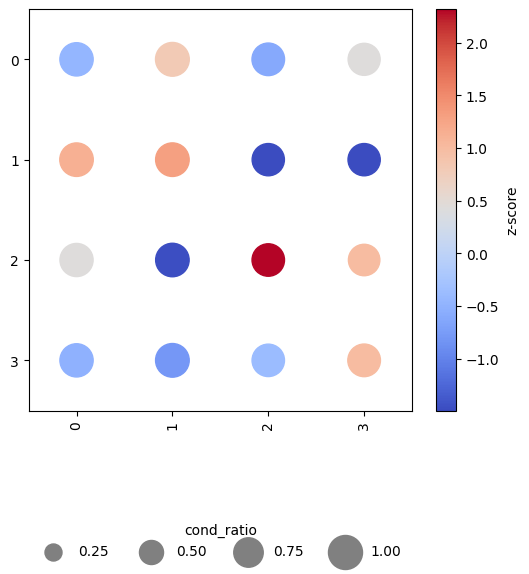

In [19]:
cozi_dotplot(res)